<class 'pandas.DataFrame'>
RangeIndex: 88206 entries, 0 to 88205
Data columns (total 44 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  88206 non-null  str    
 1   age                         88206 non-null  int64  
 2   gender                      88206 non-null  str    
 3   education_level             88206 non-null  str    
 4   school_type                 88206 non-null  str    
 5   family_income               88206 non-null  str    
 6   parent_education            82449 non-null  str    
 7   urban_rural                 88206 non-null  str    
 8   previous_exam_score         88206 non-null  float64
 9   previous_gpa                81347 non-null  float64
 10  attendance_percentage       79570 non-null  float64
 11  assignment_completion_rate  88206 non-null  float64
 12  class_participation         88206 non-null  str    
 13  study_hours_per_day         88206 non-null

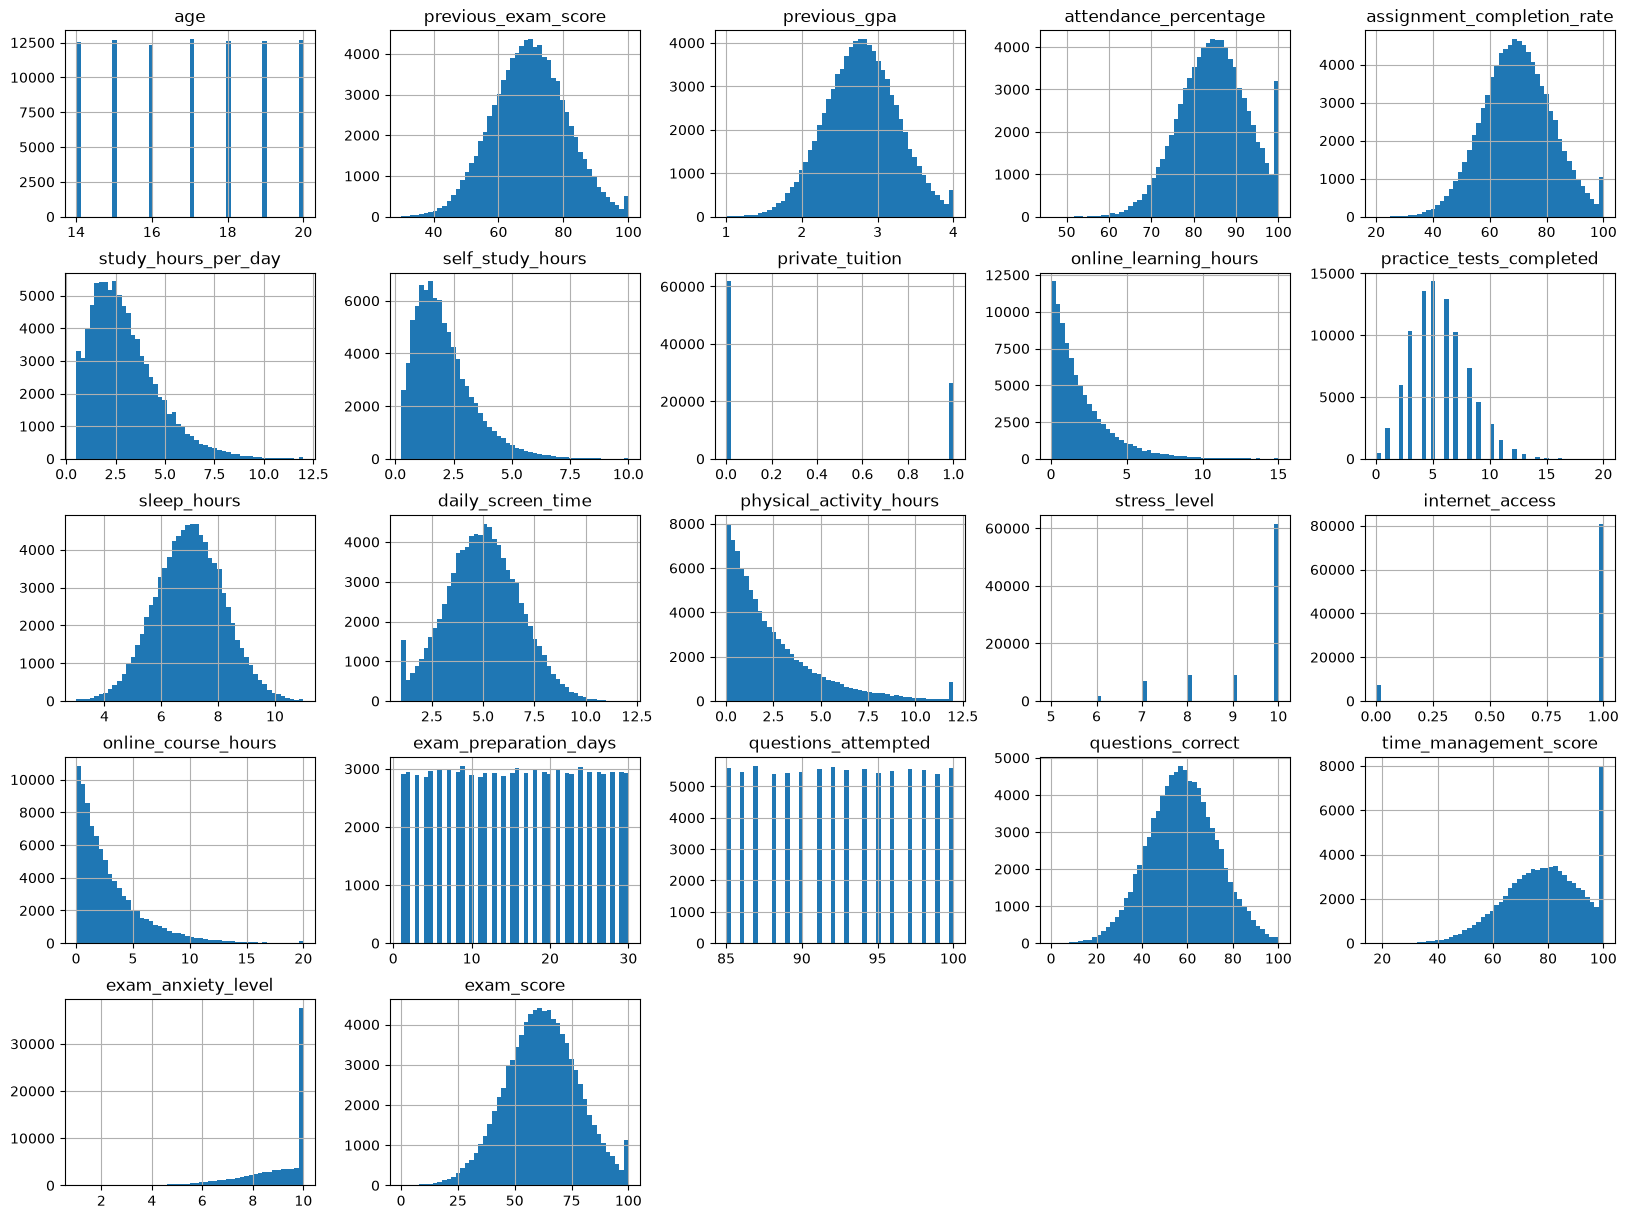

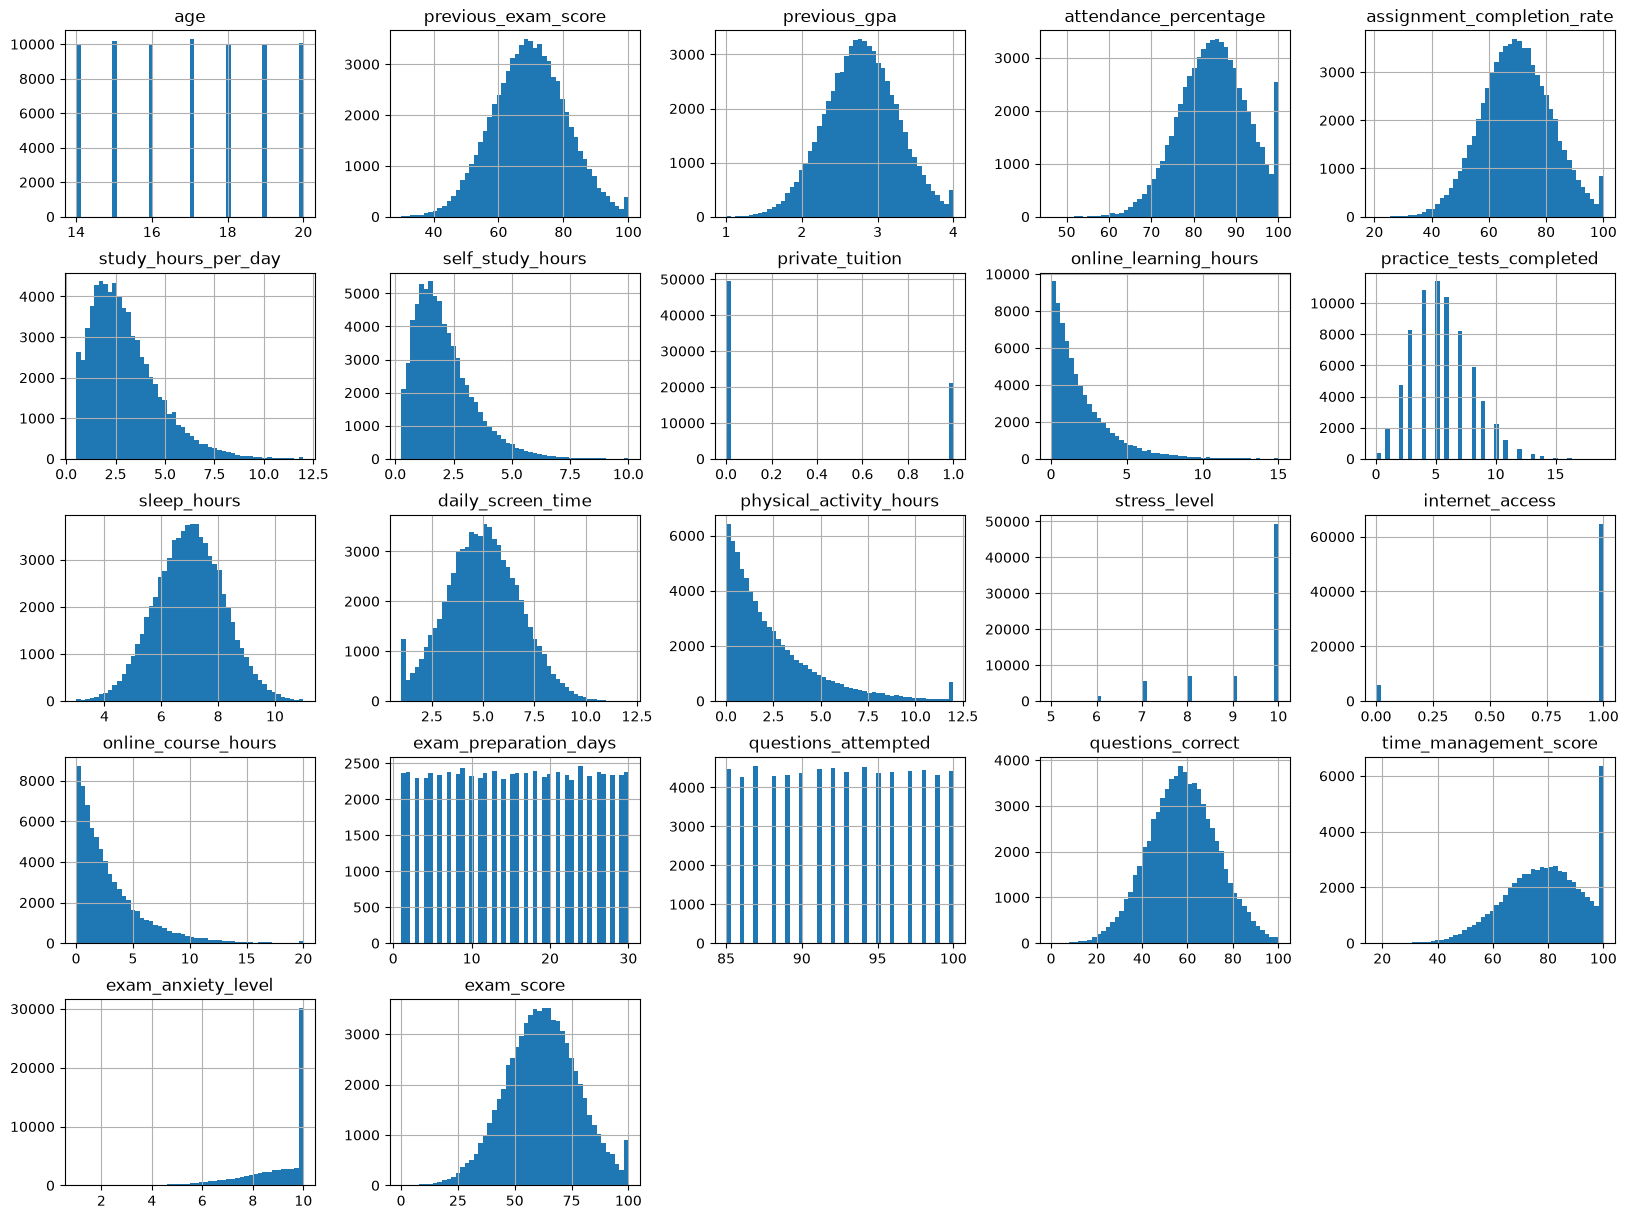

In [48]:
import pandas as pd
import os
import numpy as np
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import OneHotEncoder
%matplotlib inline
import matplotlib.pyplot as plt
def load_data():
    csv_path = os.path.join("datasets", "student_exam_performance.csv")
    return pd.read_csv(csv_path) 
stud_ex_perf = load_data()

stud_ex_perf["performance_grade"] = stud_ex_perf["performance_grade"].replace(stud_ex_perf["performance_grade"].unique(), [5.0, 4.0, 3.0, 2.0, 2.0])
stud_ex_perf = stud_ex_perf[~stud_ex_perf["gender"].isin(["Other"])]
stud_ex_perf = stud_ex_perf[~stud_ex_perf["school_type"].isin(["Charter"])]
stud_ex_perf = stud_ex_perf.reset_index(drop=True)  

stud_ex_perf.info()
len(stud_ex_perf)

stud_ex_perf.hist(bins = 50 ,figsize = (20, 15))
plt.show()

split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(stud_ex_perf, stud_ex_perf[["gender"]]):
    strat_train_set = stud_ex_perf.loc[train_index]
    strat_test_set = stud_ex_perf.loc[test_index] 

strat_train_set.hist(bins = 50 ,figsize = (20, 15))
plt.show()